# **DM PRACTICAL: AI Based Internship Recommendation system**
## Team members:
### DIV - D | Batch - D1
230090107043 - Hetvi Doshi  
230090107119 - Aryan Patel  

### DIV - D | Batch - D3
230090107023 - Rushang Desai  
230090107034 - Fenil Dudhat  


### **Data Overview and Data Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_original = pd.read_csv("internships.csv")

In [3]:
df_dirty = df_original.copy()

In [4]:
df_dirty.loc[0, "stipend"] = np.nan
df_dirty.loc[1, "Company name"] = np.nan

df_dirty = pd.concat([df_dirty, df_dirty.iloc[[2]]], ignore_index=True)

df_dirty.loc[3, "Role"] = " software development "
df_dirty.loc[4, "offline / online"] = "online "

print("Dirty data sample:")
print(df_dirty.head())

Dirty data sample:
  Internship Id Company name Internship location offline / online  \
0      INT-1000     Deloitte  Bengaluru (Hybrid)           Hybrid   
1      INT-1001          NaN           Hyderabad           Online   
2      INT-1002     Deloitte           Bengaluru          Offline   
3      INT-1003     Deloitte           Bengaluru           Online   
4      INT-1004     Deloitte  Hyderabad (Hybrid)          online    

         stipend                                     skill required  \
0            NaN                       Selenium, JIRA, Bug Tracking   
1  ₹34,442/month                            JavaScript, Python, SQL   
2  ₹34,959/month        Figma, User Research, Adobe XD, Prototyping   
3  ₹34,974/month           Sales, Client Relations, Market Analysis   
4  ₹32,647/month  Automation Testing, Bug Tracking, Manual Testi...   

                    experience  \
0                    0-1 years   
1                      Fresher   
2           Portfolio required   
3  

In [5]:
df_clean = df_dirty.copy()
df_clean["stipend"].fillna("₹0/month", inplace=True)
df_clean["Company name"].fillna("Unknown", inplace=True)

df_clean.drop_duplicates(inplace=True)

df_clean["Role"] = df_clean["Role"].str.strip().str.title()
df_clean["offline / online"] = df_clean["offline / online"].str.strip().str.title()

df_clean.reset_index(drop=True, inplace=True)

print("\nCleaned data sample:")
print(df_clean.head())


Cleaned data sample:
  Internship Id Company name Internship location offline / online  \
0      INT-1000     Deloitte  Bengaluru (Hybrid)           Hybrid   
1      INT-1001      Unknown           Hyderabad           Online   
2      INT-1002     Deloitte           Bengaluru          Offline   
3      INT-1003     Deloitte           Bengaluru           Online   
4      INT-1004     Deloitte  Hyderabad (Hybrid)           Online   

         stipend                                     skill required  \
0       ₹0/month                       Selenium, JIRA, Bug Tracking   
1  ₹34,442/month                            JavaScript, Python, SQL   
2  ₹34,959/month        Figma, User Research, Adobe XD, Prototyping   
3  ₹34,974/month           Sales, Client Relations, Market Analysis   
4  ₹32,647/month  Automation Testing, Bug Tracking, Manual Testi...   

                    experience  \
0                    0-1 years   
1                      Fresher   
2           Portfolio required   


In [6]:
print("Original dataset shape:", df_original.shape)
print("Dirty dataset shape:", df_dirty.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (354, 13)
Dirty dataset shape: (355, 13)
Cleaned dataset shape: (354, 13)


In [7]:
df = pd.read_csv("internships.csv")
df.shape

(354, 13)

In [8]:
df.columns

Index(['Internship Id', 'Company name', 'Internship location',
       'offline / online', 'stipend', 'skill required', 'experience',
       'about the job', 'deadline for apply', 'number of opening', 'duration',
       'Role', 'Website link of company (optional)'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Internship Id                       354 non-null    object
 1   Company name                        354 non-null    object
 2   Internship location                 354 non-null    object
 3   offline / online                    354 non-null    object
 4   stipend                             354 non-null    object
 5   skill required                      354 non-null    object
 6   experience                          354 non-null    object
 7   about the job                       354 non-null    object
 8   deadline for apply                  354 non-null    object
 9   number of opening                   354 non-null    int64 
 10  duration                            354 non-null    object
 11  Role                                354 non-null    object

In [10]:
df.head()

,Internship Id,Company name,Internship location,offline / online,stipend,skill required,experience,about the job,deadline for apply,number of opening,duration,Role,Website link of company (optional)
0,INT-1000,Deloitte,Bengaluru (Hybrid),Hybrid,"₹33,794/month","Selenium, JIRA, Bug Tracking",0-1 years,"Test software applications, identify bugs, wri...",11-11-2025,4,4 months,Quality Assurance,https://www.deloitte.com
1,INT-1001,Deloitte,Hyderabad,Online,"₹34,442/month","JavaScript, Python, SQL",Fresher,"Develop and maintain software applications, wo...",10-18-2025,4,3 months,Software Development,https://www.deloitte.com
2,INT-1002,Deloitte,Bengaluru,Offline,"₹34,959/month","Figma, User Research, Adobe XD, Prototyping",Portfolio required,"Design user interfaces, conduct user research,...",11-6-2025,11,6 months,UI/UX Design,https://www.deloitte.com
3,INT-1003,Deloitte,Bengaluru,Online,"₹34,974/month","Sales, Client Relations, Market Analysis",Strong communication skills,"Support sales processes, conduct market resear...",11-1-2025,15,3 months,Business Development,https://www.deloitte.com
4,INT-1004,Deloitte,Hyderabad (Hybrid),Hybrid,"₹32,647/month","Automation Testing, Bug Tracking, Manual Testi...",Understanding of SDLC,"Test software applications, identify bugs, wri...",9-30-2025,21,4 months,Quality Assurance,https://www.deloitte.com


In [11]:
df.tail()

,Internship Id,Company name,Internship location,offline / online,stipend,skill required,experience,about the job,deadline for apply,number of opening,duration,Role,Website link of company (optional)
349,INT-1349,IDRBT,Hyderabad,Online,"₹13,838/month","Market Analysis, Client Relations, CRM",Strong communication skills,"Support sales processes, conduct market resear...",11-7-2025,25,3 months,Business Development,https://www.idrbt.ac.in
350,INT-1350,IDRBT,Hyderabad,Offline,"₹12,886/month","Selenium, Manual Testing, Automation Testing",0-1 years,"Test software applications, identify bugs, wri...",11-12-2025,23,2 months,Quality Assurance,https://www.idrbt.ac.in
351,INT-1351,IDRBT,Hyderabad (Hybrid),Hybrid,"₹14,779/month","Negotiation, Client Relations, Market Analysis...",Strong communication skills,"Support sales processes, conduct market resear...",10-24-2025,17,6 months,Business Development,https://www.idrbt.ac.in
352,INT-1352,IDRBT,Hyderabad (Hybrid),Hybrid,"₹14,806/month","Figma, Adobe XD, User Research",0-1 years,"Design user interfaces, conduct user research,...",10-5-2025,11,6 months,UI/UX Design,https://www.idrbt.ac.in
353,INT-1353,IDRBT,Hyderabad,Offline,"₹14,654/month","Google Analytics, SEO, Content Marketing, PPC,...",0-1 years,"Manage digital campaigns, create content strat...",10-21-2025,15,3 months,Digital Marketing,https://www.idrbt.ac.in


In [12]:
df.describe()

,number of opening
count,354.000000
mean,13.881356
std,6.981768
min,2.000000
25%,8.000000
50%,14.000000
75%,20.000000
max,25.000000


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
number of opening,354.0,13.881356,6.981768,2.0,8.0,14.0,20.0,25.0


In [14]:
df.isnull()

,Internship Id,Company name,Internship location,offline / online,stipend,skill required,experience,about the job,deadline for apply,number of opening,duration,Role,Website link of company (optional)
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,False,False,False,False,False,False,False,False,False,False,False,False,False
350,False,False,False,False,False,False,False,False,False,False,False,False,False
351,False,False,False,False,False,False,False,False,False,False,False,False,False
352,False,False,False,False,False,False,False,False,False,False,False,False,False


In [15]:
df.isnull().sum()

,0
Internship Id,0
Company name,0
Internship location,0
offline / online,0
stipend,0
skill required,0
experience,0
about the job,0
deadline for apply,0
number of opening,0


In [16]:
mode_count = df["offline / online"].value_counts()
print(mode_count)

offline / online
Online     141
Hybrid     111
Offline    102
Name: count, dtype: int64


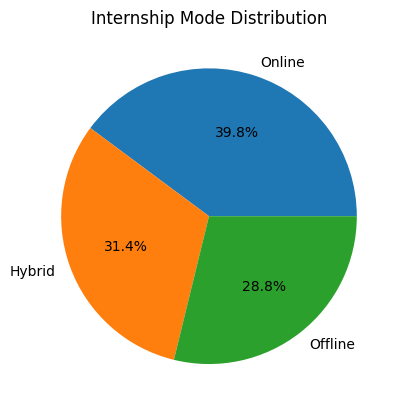

In [17]:
mode_count.plot(kind="pie", autopct="%1.1f%%")
plt.title("Internship Mode Distribution")
plt.ylabel("")
plt.show()

In [18]:
roles = df["Role"].value_counts()
print(roles)

Role
UI/UX Design            39
Quality Assurance       36
Business Development    34
Digital Marketing       32
Operations              30
HR                      29
Data Science            29
Software Development    27
Machine Learning        27
Product Management      26
Finance                 23
Content Writing         22
Name: count, dtype: int64


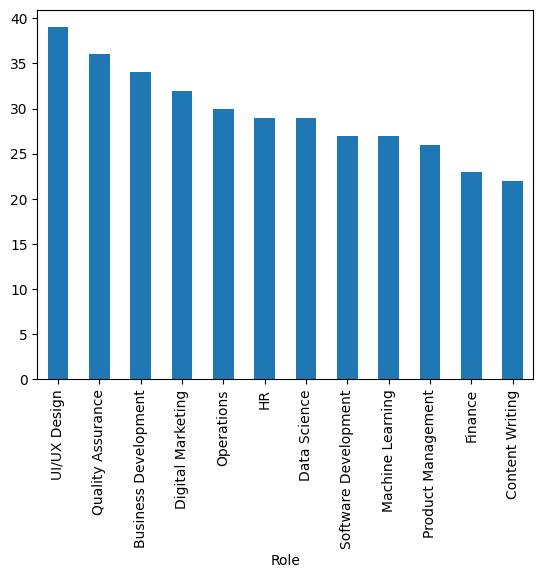

In [19]:
roles.plot(kind='bar')
plt.show()

In [20]:
locations = df["Internship location"].value_counts()
print(locations)

Internship location
Bengaluru                      79
Bengaluru (Hybrid)             38
Delhi                          36
Hyderabad                      25
Hyderabad (Hybrid)             24
Mumbai                         23
Pune                           22
Remote                         18
Chennai (Hybrid)               17
Chennai                        14
Delhi (Hybrid)                 13
Gurgaon                         9
Mumbai (Hybrid)                 7
Thiruvananthapuram              7
Noida                           5
Mangalore (Hybrid)              5
Mangalore                       3
Pune (Hybrid)                   3
Sydney                          2
Sydney (Hybrid)                 2
Thiruvananthapuram (Hybrid)     2
Name: count, dtype: int64


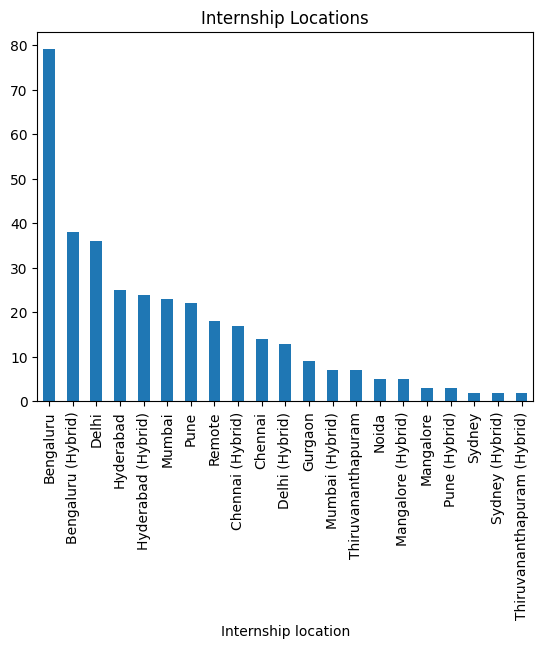

In [21]:
locations.plot(kind='bar')
plt.title("Internship Locations")
plt.show()

In [22]:
print(df["duration"].value_counts())

duration
2 months     80
4 months     73
6 months     73
3 months     70
12 months    58
Name: count, dtype: int64


In [23]:
df["stipend_clean"] = df["stipend"].str.replace("₹|,|/month", "", regex=True)

df["stipend_clean"] = pd.to_numeric(df["stipend_clean"], errors="coerce")

print("Average stipend:", df["stipend_clean"].mean())
print("Max stipend:", df["stipend_clean"].max())
print("Min stipend:", df["stipend_clean"].min())

Average stipend: 37804.443502824855
Max stipend: 99521
Min stipend: 12705


### **Classification**

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [25]:
df_clf = df[["Role", "Internship location", "stipend_clean", "duration", "offline / online"]]

df_clf = df_clf.dropna()

In [26]:
df_clf["duration"] = df_clf["duration"].str.extract("(\d+)").astype(int)

In [27]:
le_role = LabelEncoder()
le_loc = LabelEncoder()
le_mode = LabelEncoder()

df_clf["Role"] = le_role.fit_transform(df_clf["Role"])
df_clf["Internship location"] = le_loc.fit_transform(df_clf["Internship location"])
df_clf["offline / online"] = le_mode.fit_transform(df_clf["offline / online"])

In [28]:
X = df_clf.drop("offline / online", axis=1)
y = df_clf["offline / online"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [30]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7183098591549296
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        22
           1       0.58      0.52      0.55        21
           2       0.65      0.71      0.68        28

    accuracy                           0.72        71
   macro avg       0.73      0.72      0.72        71
weighted avg       0.72      0.72      0.72        71



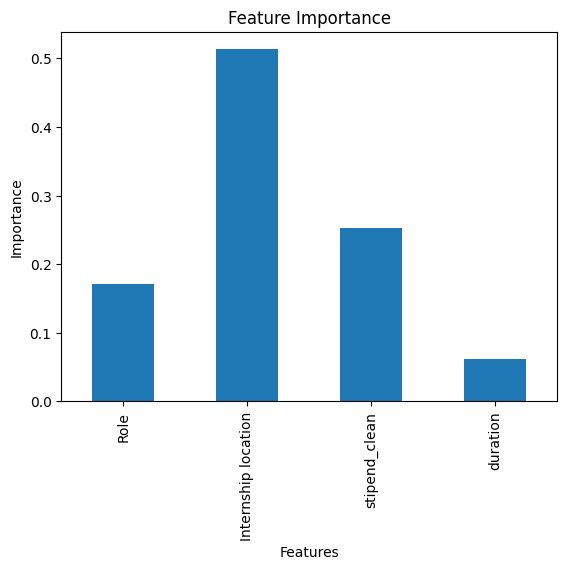

In [31]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.plot(kind='bar')

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

### **Association Rule Mining**

In [32]:
!pip install mlxtend

In [33]:
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [34]:
df_arm = df[["Role", "Internship location", "duration"]].dropna()
df_arm = pd.get_dummies(df_arm)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [35]:
freq_items = apriori(df_arm, min_support=0.02, use_colnames=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [36]:
rules = association_rules(freq_items, metric="confidence", min_threshold=0.3)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [37]:
print(rules.head())

                 antecedents           consequents  antecedent support  \
0     (Role_Content Writing)   (duration_6 months)            0.062147   
1        (Role_Data Science)  (duration_12 months)            0.081921   
2    (Role_Machine Learning)   (duration_3 months)            0.076271   
3  (Role_Product Management)   (duration_2 months)            0.073446   
4   (Role_Quality Assurance)   (duration_6 months)            0.101695   

   consequent support   support  confidence      lift  representativity  \
0            0.206215  0.028249    0.454545  2.204234               1.0   
1            0.163842  0.031073    0.379310  2.315101               1.0   
2            0.197740  0.025424    0.333333  1.685714               1.0   
3            0.225989  0.022599    0.307692  1.361538               1.0   
4            0.206215  0.031073    0.305556  1.481735               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
0  0.015433    1.455273       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

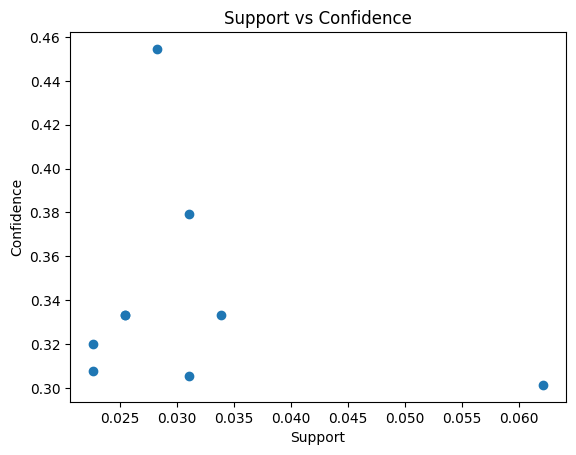

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [38]:
import matplotlib.pyplot as plt

plt.scatter(rules['support'], rules['confidence'])

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")

plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

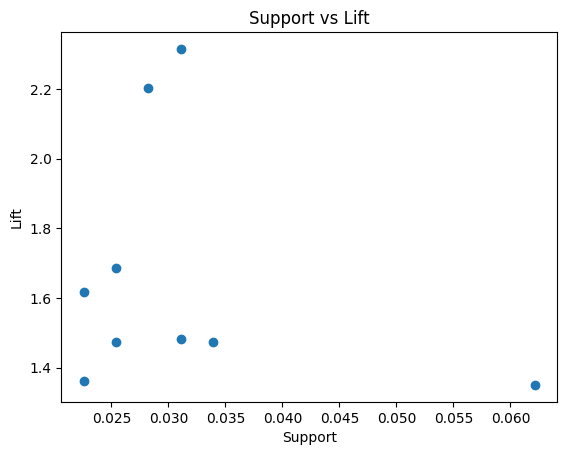

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [39]:
plt.scatter(rules['support'], rules['lift'])

plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Support vs Lift")

plt.show()

### **Clustering**

In [40]:
from sklearn.cluster import KMeans

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [41]:
df_cluster = df[["stipend_clean", "duration"]].copy()
df_cluster = df_cluster.dropna()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [42]:
df_cluster["duration"] = df_cluster["duration"].str.extract("(\d+)").astype(int)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [43]:
kmeans = KMeans(n_clusters=3, random_state=0)

df_cluster["Cluster"] = kmeans.fit_predict(df_cluster)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [44]:
print(df_cluster.head())

   stipend_clean  duration  Cluster
0          33794         4        0
1          34442         3        0
2          34959         6        0
3          34974         3        0
4          32647         4        2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

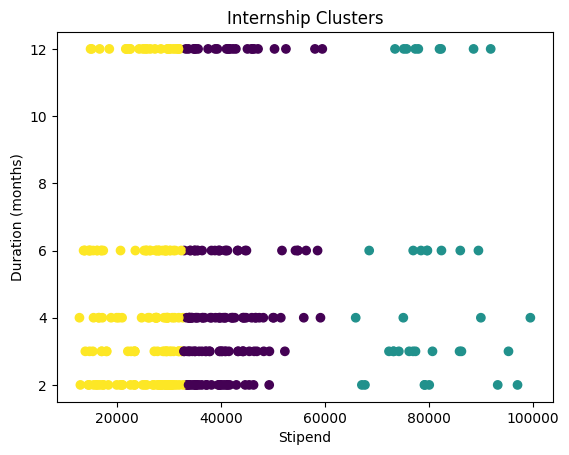

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [45]:
plt.scatter(df_cluster["stipend_clean"], df_cluster["duration"], c=df_cluster["Cluster"])

plt.xlabel("Stipend")
plt.ylabel("Duration (months)")
plt.title("Internship Clusters")

plt.show()


- Classification helps predict internship mode (online/offline)  
- Association rules show relationships between role, location, and duration  
- Clustering groups similar internships based on stipend and duration  

### **Text Mining Technique**

In [46]:
#TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Fill missing values
df["skill required"] = df["skill required"].fillna("")

# Apply TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=10)
tfidf = vectorizer.fit_transform(df["skill required"])

# Convert to DataFrame
tfidf_df = pd.DataFrame(tfidf.toarray(), columns=vectorizer.get_feature_names_out())

print(tfidf_df.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   analysis  analytics    market  media  python  relations  research  social  \
0  0.000000        0.0  0.000000    0.0     0.0   0.000000       0.0     0.0   
1  0.000000        0.0  0.000000    0.0     1.0   0.000000       0.0     0.0   
2  0.000000        0.0  0.000000    0.0     0.0   0.000000       1.0     0.0   
3  0.584901        0.0  0.584901    0.0     0.0   0.561944       0.0     0.0   
4  0.000000        0.0  0.000000    0.0     0.0   0.000000       0.0     0.0   

   testing  wireframing  
0      0.0          0.0  
1      0.0          0.0  
2      0.0          0.0  
3      0.0          0.0  
4      1.0          0.0  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Converts text → numbers  
Finds important skills

Example:

"Python, ML" → [0.7, 0.5]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

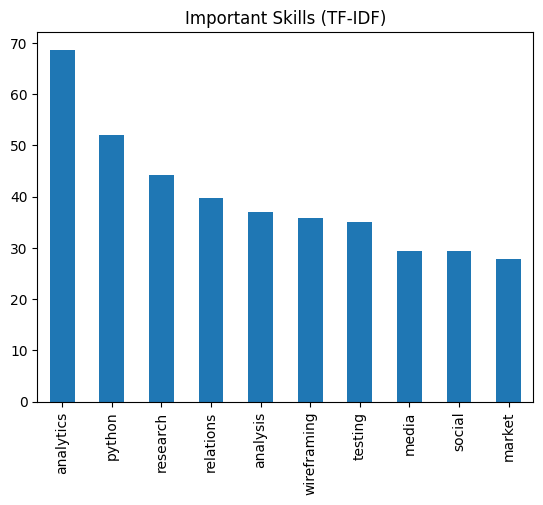

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [47]:
import matplotlib.pyplot as plt

tfidf_df.sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Important Skills (TF-IDF)")
plt.show()

### **Web mining technique**

In [48]:
!pip install requests beautifulsoup4

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

In [49]:
import requests
import pandas as pd

# Fetch data from API
url = "https://remoteok.com/api"
headers = {'User-Agent': 'Mozilla/5.0'}

response = requests.get(url, headers=headers)
data = response.json()[1:]   # skip first element

# Extract useful fields
jobs = []
for job in data:
    jobs.append({
        "Company": job.get("company"),
        "Role": job.get("position"),
        "Location": job.get("location"),
        "Skills": ", ".join(job.get("tags", []))
    })

# Create DataFrame
df_web = pd.DataFrame(jobs)

print(df_web.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

             Company                                            Role  \
0          Alimentiv      Imaging Research and Development Associate   
1          Headlight             Learning and Development Specialist   
2            Sureify                               VP of Engineering   
3  LifeStance Health                Licensed Mental Health Counselor   
4          Spellbook  Business Development Representative Enterprise   

     Location                                             Skills  
0              design, training, support, voice, management, ...  
1              system, training, support, adult, microsoft, m...  
2          US  technical, software, lead, operational, engine...  
3  Tacoma, WA  lead, medical, health, healthcare, full-time, ...  
4              saas, support, software, test, manager, micros...  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

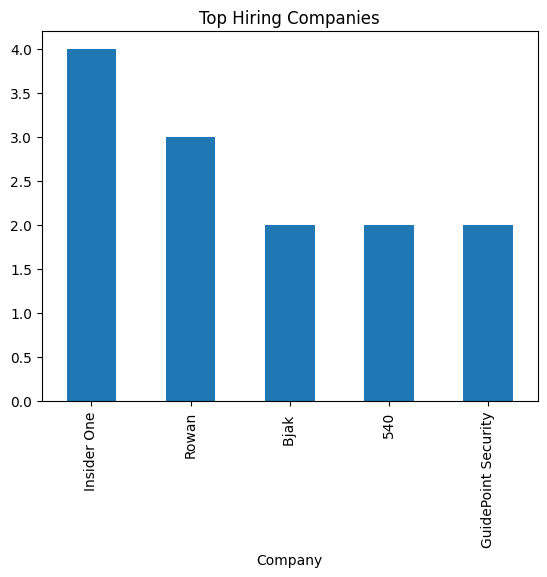

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [50]:
import matplotlib.pyplot as plt

df_web["Company"].value_counts().head(5).plot(kind="bar")
plt.title("Top Hiring Companies")
plt.show()